# Task 1 — Exploring and Visualizing a Simple Dataset (Iris)

## Objective
Learn how to:
- Load a dataset using **pandas**
- Inspect structure using `.shape`, `.columns`, `.head()`
- Create basic visualizations using **matplotlib** and **seaborn**:
  - Scatter plot (relationships)
  - Histogram (distribution)
  - Box plot (outliers / spread)

## Dataset
Iris dataset (available via seaborn, or CSV)

## Deliverables
- Dataset overview and summary
- Required plots (scatter, histogram, boxplot)
- Short conclusions (what you observed)

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# If you have iris.csv, place it in: data/iris.csv
DATA_PATH = Path("../data/iris.csv")

# Where to save figures (optional but professional)
FIG_DIR = Path("../outputs/task1_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Step 1 — Load Dataset

We will try:
1) Load from local CSV (if available)  
2) Otherwise load from seaborn built-in iris dataset  

This makes the notebook portable and easy to run on any system.

In [11]:
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    source = f"CSV: {DATA_PATH}"
else:
    df = sns.load_dataset("iris")
    source = "seaborn.load_dataset('iris')"

print("Data source:", source)
print("Original columns:", df.columns.tolist())

def _norm_col(c: str) -> str:
    c = str(c).strip().lower()
    c = c.replace(" ", "_").replace("-", "_").replace(".", "_").replace("/", "_")
    c = c.replace("(", "").replace(")", "")
    return c

# Normalize column names
df.columns = [_norm_col(c) for c in df.columns]

# Auto-rename common Iris column variants to a single standard
variants_map = {
    "sepal_length": {"sepal_length", "sepallengthcm", "sepal_length_cm", "sepal_length_cm_", "sepal_lengthcm"},
    "sepal_width":  {"sepal_width",  "sepalwidthcm",  "sepal_width_cm",  "sepal_widthcm"},
    "petal_length": {"petal_length", "petallengthcm", "petal_length_cm", "petal_lengthcm"},
    "petal_width":  {"petal_width",  "petalwidthcm",  "petal_width_cm",  "petal_widthcm"},
    "species":      {"species", "variety", "class", "target", "label"},
}

rename_dict = {}
for col in df.columns:
    for canonical, varset in variants_map.items():
        if col in varset:
            rename_dict[col] = canonical

df = df.rename(columns=rename_dict)

print("Standardized columns:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())

Data source: CSV: ..\data\iris.csv
Original columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Standardized columns: ['id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Shape: (150, 6)


,id,sepal_length,sepal_width,petal_length,petal_width,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
print("Columns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes)

print("\nInfo:")
df.info()

Columns: ['id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:


id                int64
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            150 non-null    int64  
 1   sepal_length  150 non-null    float64
 2   sepal_width   150 non-null    float64
 3   petal_length  150 non-null    float64
 4   petal_width   150 non-null    float64
 5   species       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [13]:
display(df.describe())

# If species is present, show class counts
if "species" in df.columns:
    print("\nSpecies distribution:")
    display(df["species"].value_counts())

,id,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



Species distribution:


species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [14]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
print("Missing values (%):")
display(missing_pct[missing_pct > 0].to_frame("missing_%"))

dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Missing values (%):


,missing_%


Duplicate rows: 0


## Step 2 — Visualizations (Required)

We will create:
1. **Scatter plot** to analyze relationships  
2. **Histogram** to examine distribution  
3. **Box plot** to detect outliers and spread  

We will also keep plots clean with titles, labels, and legends.

In [15]:
def save_fig(filename: str) -> None:
    """Save the current matplotlib figure to the outputs folder."""
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

Saved: ..\outputs\task1_figures\scatter_sepal_length_vs_petal_length.png


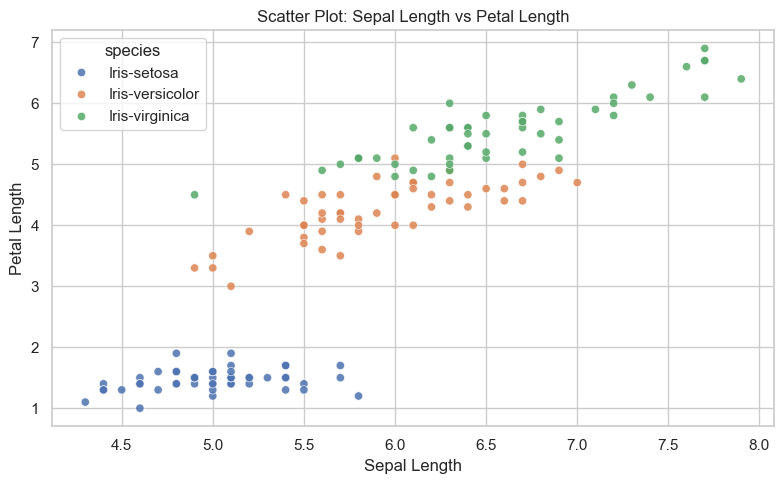

In [16]:
# Helper to ensure required columns exist
required = ["sepal_length", "petal_length"]
missing = [c for c in required if c not in df.columns]

if missing:
    print("Scatter plot skipped.")
    print("Missing required columns:", missing)
    print("Available columns:", df.columns.tolist())
else:
    ax = sns.scatterplot(
        data=df,
        x="sepal_length",
        y="petal_length",
        hue="species" if "species" in df.columns else None,
        alpha=0.85
    )
    ax.set_title("Scatter Plot: Sepal Length vs Petal Length")
    ax.set_xlabel("Sepal Length")
    ax.set_ylabel("Petal Length")

    # Save safely (if save_fig exists)
    try:
        save_fig("scatter_sepal_length_vs_petal_length.png")
    except Exception as e:
        print("Note: Could not save figure:", e)

    plt.show()

Saved: ..\outputs\task1_figures\scatter_petal_length_vs_petal_width.png


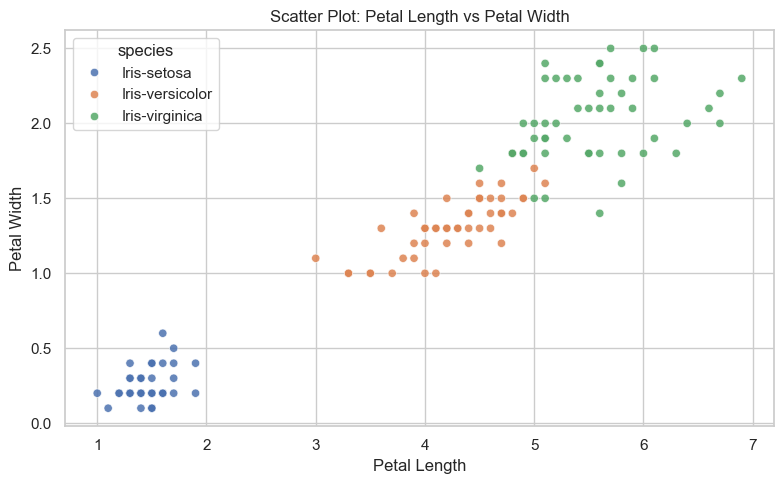

In [17]:
required = ["petal_length", "petal_width"]
missing = [c for c in required if c not in df.columns]

if missing:
    print("Scatter plot skipped.")
    print("Missing required columns:", missing)
    print("Available columns:", df.columns.tolist())
else:
    ax = sns.scatterplot(
        data=df,
        x="petal_length",
        y="petal_width",
        hue="species" if "species" in df.columns else None,
        alpha=0.85
    )
    ax.set_title("Scatter Plot: Petal Length vs Petal Width")
    ax.set_xlabel("Petal Length")
    ax.set_ylabel("Petal Width")

    try:
        save_fig("scatter_petal_length_vs_petal_width.png")
    except Exception as e:
        print("Note: Could not save figure:", e)

    plt.show()

Saved: ..\outputs\task1_figures\hist_petal_length.png


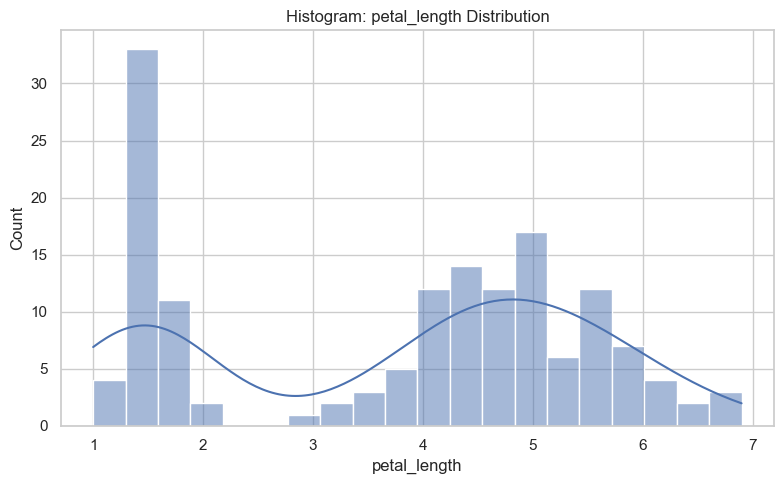

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if not num_cols:
    print("Histogram skipped: no numeric columns found.")
    print("Available columns:", df.columns.tolist())
else:
    feature = "petal_length" if "petal_length" in df.columns else num_cols[0]

    ax = sns.histplot(df[feature].dropna(), bins=20, kde=True)
    ax.set_title(f"Histogram: {feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

    try:
        save_fig(f"hist_{feature}.png")
    except Exception as e:
        print("Note: Could not save figure:", e)

    plt.show()

Saved: ..\outputs\task1_figures\hist_all_numeric_features.png


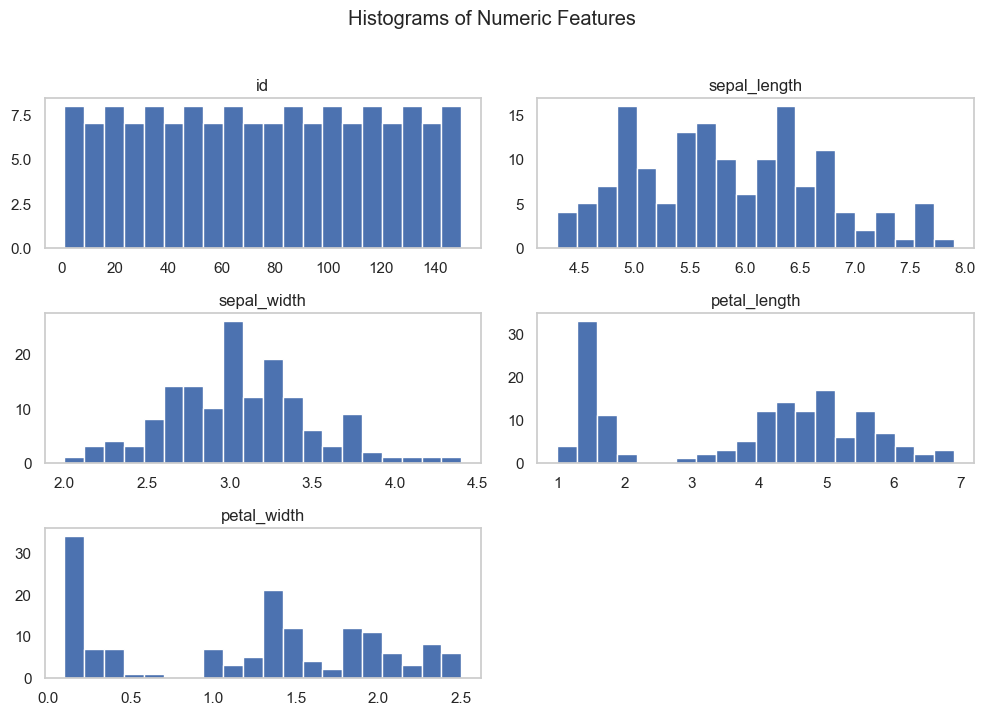

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if not num_cols:
    print("Multi-hist skipped: no numeric columns found.")
else:
    df[num_cols].hist(bins=20, figsize=(10, 7), grid=False)
    plt.suptitle("Histograms of Numeric Features", y=1.02)

    try:
        save_fig("hist_all_numeric_features.png")
    except Exception as e:
        print("Note: Could not save figure:", e)

    plt.show()

Saved: ..\outputs\task1_figures\box_petal_width_by_species.png


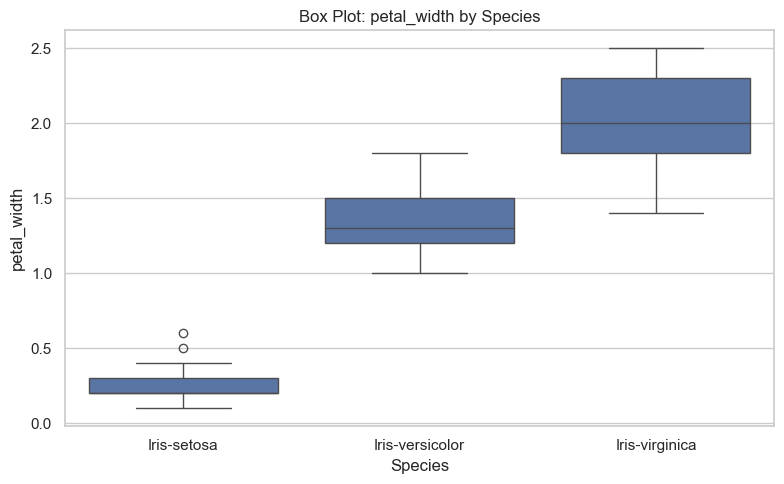

In [20]:
# Pick a default numeric feature for boxplot
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if not num_cols:
    print("Box plot skipped: no numeric columns found.")
else:
    feature = "petal_width" if "petal_width" in df.columns else num_cols[0]

    if "species" in df.columns:
        ax = sns.boxplot(data=df, x="species", y=feature)
        ax.set_xlabel("Species")
        ax.set_title(f"Box Plot: {feature} by Species")
    else:
        ax = sns.boxplot(data=df, y=feature)
        ax.set_title(f"Box Plot: {feature}")
        ax.set_xlabel("")

    ax.set_ylabel(feature)

    try:
        save_fig(f"box_{feature}.png" if "species" not in df.columns else f"box_{feature}_by_species.png")
    except Exception as e:
        print("Note: Could not save figure:", e)

    plt.show()

Saved: ..\outputs\task1_figures\box_id_by_species.png


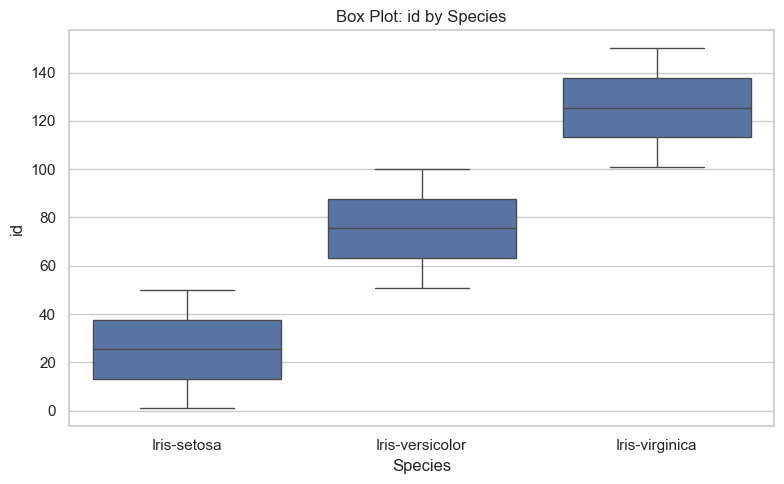

Saved: ..\outputs\task1_figures\box_sepal_length_by_species.png


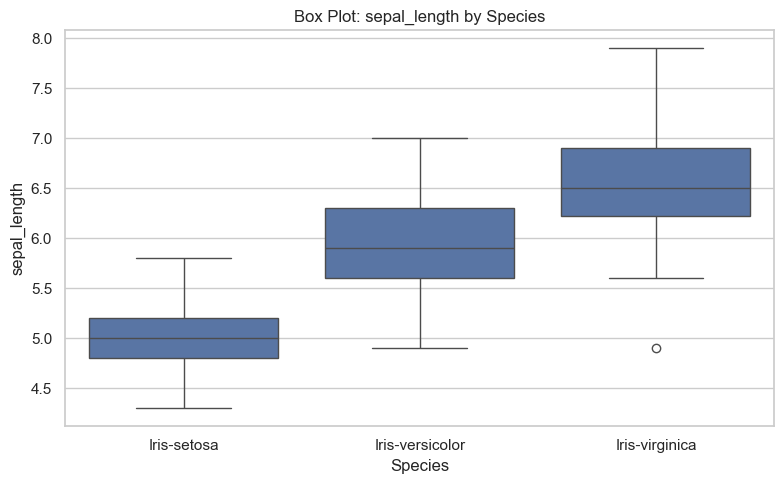

Saved: ..\outputs\task1_figures\box_sepal_width_by_species.png


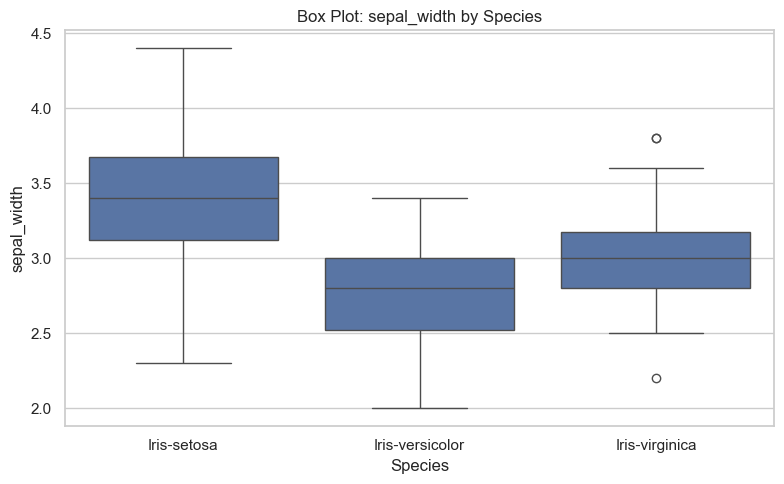

Saved: ..\outputs\task1_figures\box_petal_length_by_species.png


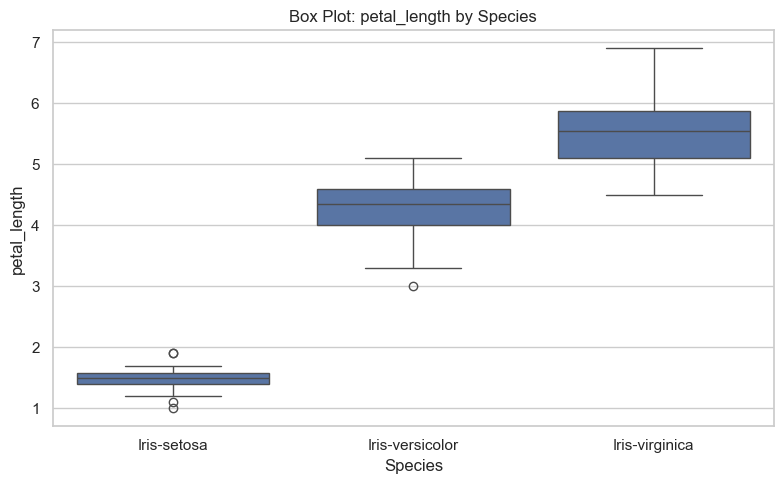

Saved: ..\outputs\task1_figures\box_petal_width_by_species.png


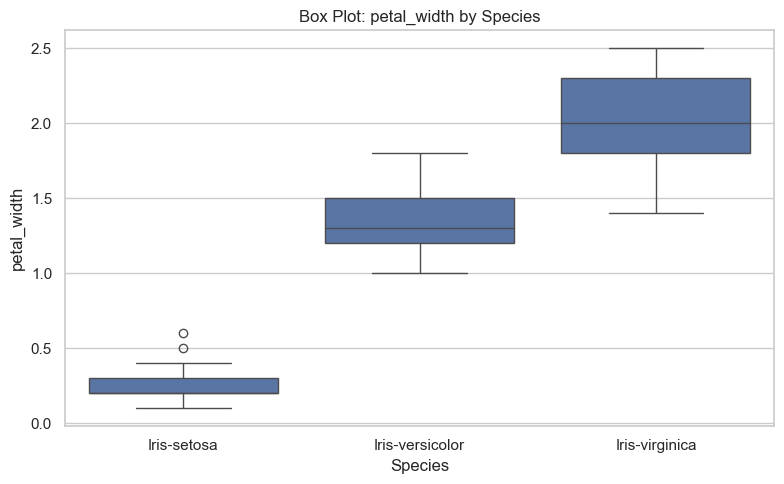

In [21]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if "species" not in df.columns:
    print("Grouped boxplots skipped: 'species' column not found.")
elif not num_cols:
    print("Grouped boxplots skipped: no numeric columns found.")
else:
    for col in num_cols:
        ax = sns.boxplot(data=df, x="species", y=col)
        ax.set_title(f"Box Plot: {col} by Species")
        ax.set_xlabel("Species")
        ax.set_ylabel(col)

        try:
            save_fig(f"box_{col}_by_species.png")
        except Exception as e:
            print("Note: Could not save figure:", e)

        plt.show()

## Optional: Pairplot (Classic Iris Visualization)

Pairplot shows relationships between all numeric features together.  
This is optional but makes the notebook more complete.

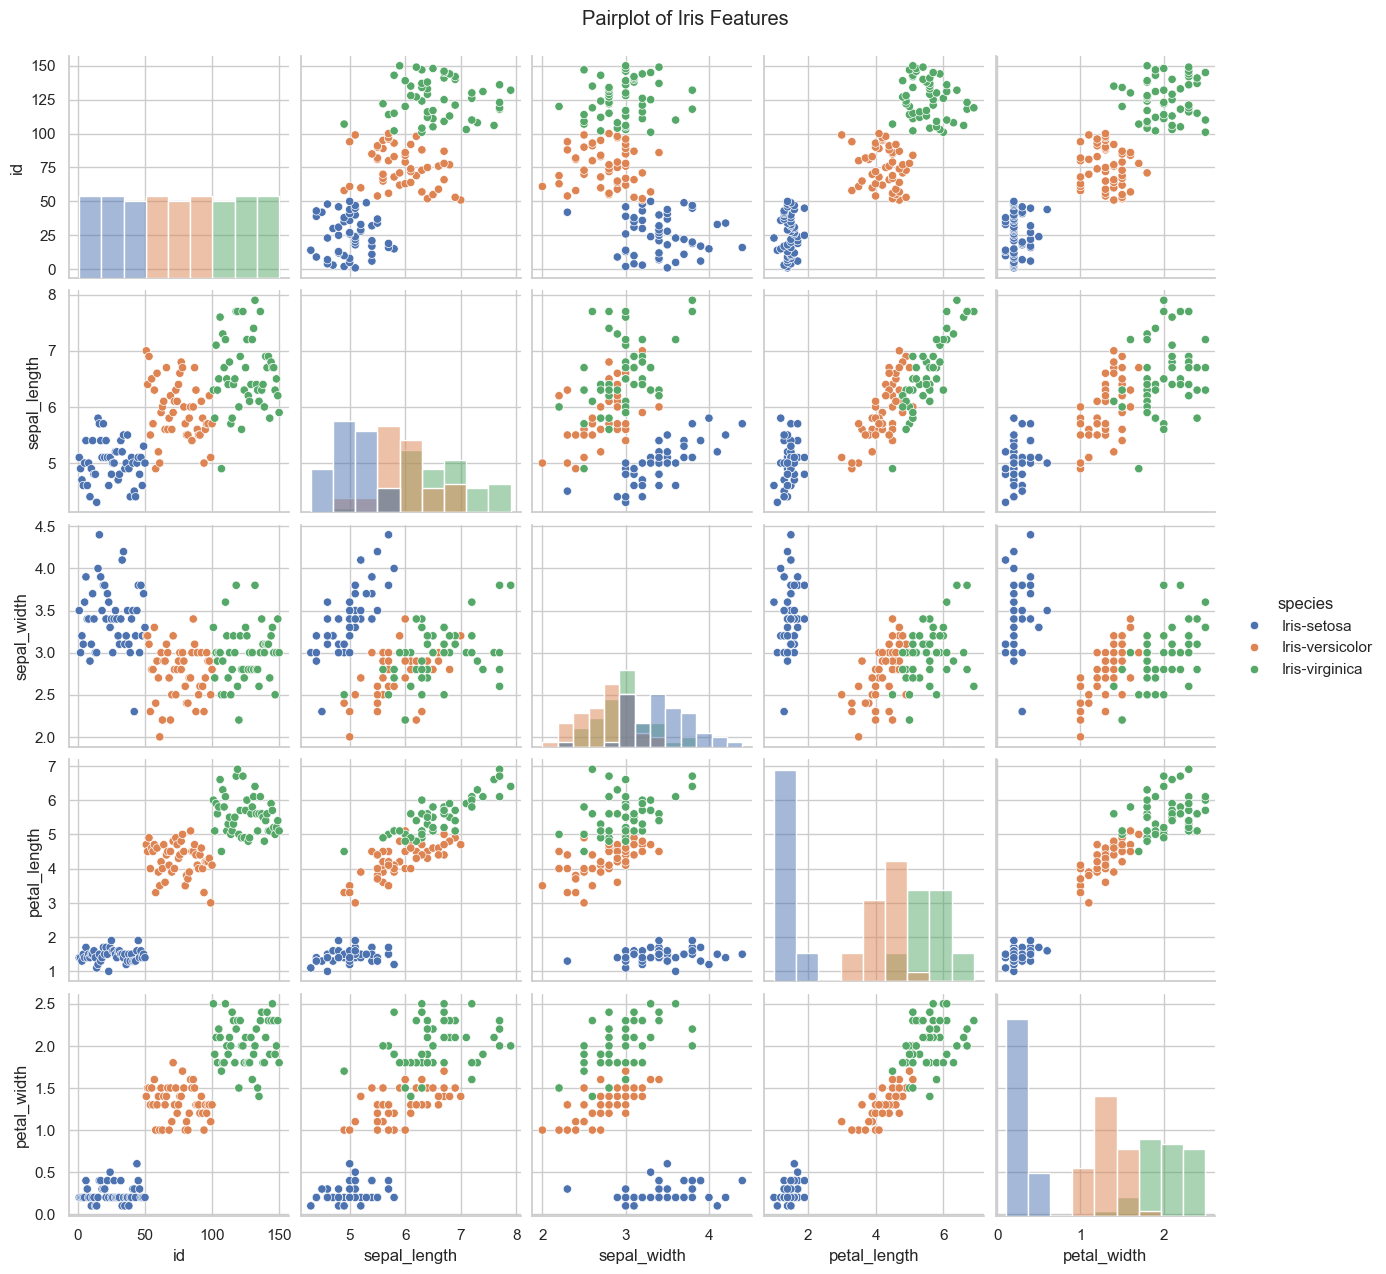

In [22]:
if "species" not in df.columns:
    print("Pairplot skipped: 'species' column not found.")
else:
    try:
        sns.pairplot(df, hue="species", diag_kind="hist")
        plt.suptitle("Pairplot of Iris Features", y=1.02)
        plt.show()
    except Exception as e:
        print("Pairplot failed (skipped). Reason:", e)

## (Optional) Correlation Heatmap

This heatmap shows correlation between numeric features.
It is not required in Task 1, but it improves the EDA report quality.

Saved: ..\outputs\task1_figures\heatmap_correlation.png


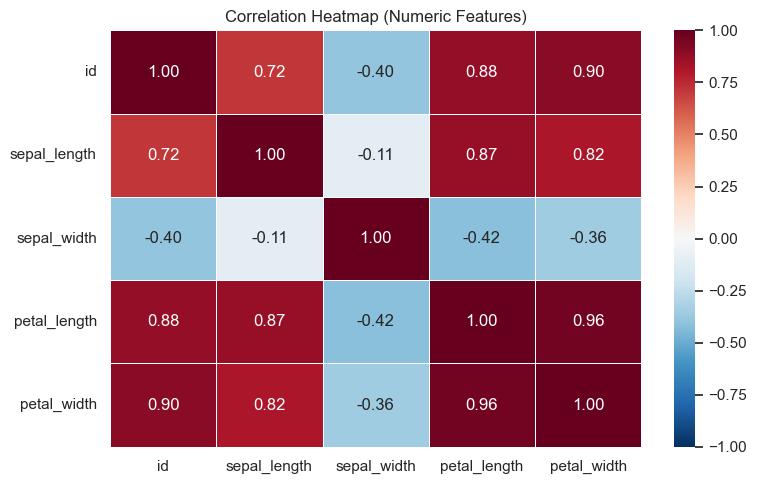

In [23]:
num_df = df.select_dtypes(include=[np.number])

if num_df.shape[1] < 2:
    print("Heatmap skipped: not enough numeric columns for correlation.")
else:
    corr = num_df.corr(numeric_only=True)

    ax = sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1, vmax=1,
        linewidths=0.5
    )
    ax.set_title("Correlation Heatmap (Numeric Features)")

    try:
        save_fig("heatmap_correlation.png")
    except Exception as e:
        print("Note: Could not save figure:", e)

    plt.show()

In [24]:
if "species" in df.columns:
    display(df.groupby("species").mean(numeric_only=True))

,id,sepal_length,sepal_width,petal_length,petal_width
species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


## Conclusion (Key Insights)
- Petal features (petal length/width) usually separate species more clearly than sepal features.
- Setosa typically forms a very distinct cluster in scatter plots.
- Versicolor and Virginica may overlap in some feature spaces.
- Box plots show different spreads and possible outliers across species.
- The Heatmap reveals a strong positive correlation between petal length and petal width, suggesting they increase together across species.
- The pair plot confirms that the combination of petal length and petal width provides the most reliable boundary for classifying the three species.

## Final Notes
This task focused on understanding dataset structure and identifying visual patterns through comprehensive Exploratory Data Analysis (EDA). By utilizing Heatmaps for correlation and Pair Plots for multivariate relationships, we successfully identified the key features that influence species classification.